# MPW2 - Computational graphs

In [ ]:
import random
import pandas as pd
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
from cgnodes import *


_____

## 1. Simple computational graph framework

Let's do a simple test with the available computational graph framework. The function to compute is $f = (x_1 x_2)^2$

![Simple computational graph](../images/simple-graph-1.jpg)

In [ ]:
# first create all ValueNode objects
x1 = ValueNode()
x2 = ValueNode()
q = ValueNode()
f = ValueNode()

# then create all <Operator>Node objects
mult = MultiplyNode(x1, x2, q)
square = SquareNode(q, f)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x1, x2], [f])

# test the graph with some random inputs
cg.forward([2.0, 4.0])
print(f"f = {f.v}")  # should print 64.0

f = 64.0


## 2. Get a dataset
### 2.1 Read data
We will use a simple dataset for this exercise with rent prices of appartments in Lausanne, as a function of the living area in square meters and the number of rooms. Define the path to the file containing the CSV data and read the data using Pandas.

In [ ]:
datafile = "lausanne-appart.csv"
dataset = pd.read_csv(datafile)
dataset.head()

,living_area,nb_rooms,rent_price
0,69,3.0,1810
1,95,3.5,2945
2,21,1.5,685
3,20,1.0,720
4,33,1.5,830


In [ ]:
# get the data as numpy arrays for the rent price and the living area
rent_price = dataset.rent_price.values
living_area = dataset.living_area.values

### 2.2 Visualize the data
Plot a scatter plot of renting price as a function of living area

In [ ]:
# in this function, x_curve and y_curve are the points of the model curve to plot (what the model estimates),
# they are optional. Theta_0, theta_1, theta_2 are the parameters of the model to display in the legend,
# also optional.
def plot_data_prediction(
        x_points,
        y_points,
        x_curve=None,
        y_curve=None,
        x_title='x',
        y_title='y',
        theta_0=None,
        theta_1=None,
        theta_2=None):
    plt.title("{} as a function of {}".format(y_title, x_title))
    plt.xlabel(x_title)   # ex "Living area (m^2)"
    plt.ylabel(y_title)   # ex "Rent (CHF)"
    plt.scatter(x_points, y_points, label="data")
    model_label = "model"
    if theta_0 is not None and theta_1 is not None:
        model_label = fr"model ($\theta_0={theta_0:.3f}$, $\theta_1={theta_1:.3f}$)"
    if theta_0 is not None and theta_1 is not None and theta_2 is not None:
        model_label += fr", $\theta_2={theta_2:.3f}$)"
    if x_curve is not None and y_curve is not None:
        plt.plot(x_curve, y_curve, color="red", label=model_label)
    plt.legend()
    plt.grid(True)
    plt.show()

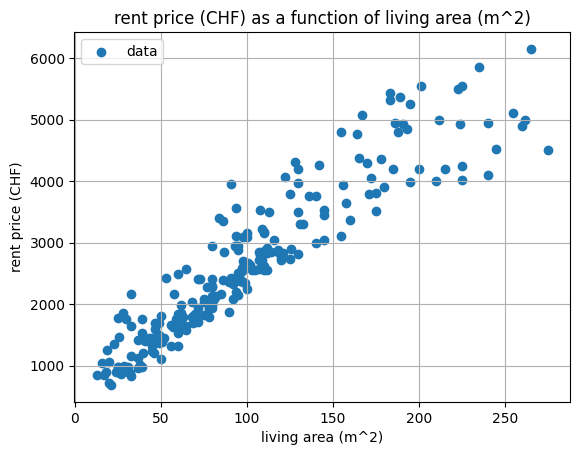

In [ ]:
plot_data_prediction(living_area, rent_price, x_title='living area (m^2)', y_title='rent price (CHF)')

## 3. Normal equations for linear regression

The simplest regression model is a linear model defined with the parameters $\theta$ as follows:

\begin{equation*}
	\hat{y} = h_{\theta}(\mathbf{x}) = \theta_{0} + \theta_{1} x
\end{equation*}

We can find the optimal parameters $\theta$ for linear regression by minimizing the mean squared error (MSE) between the predicted values and the actual values. The MSE loss is given by:

\begin{equation*}
	J(\theta) = \frac{1}{2N} \sum_{n=1}^{N} (\hat{y}_{n} - y_{n})^{2}
\end{equation*}

This is a classical optimization problem that can be solved using calculus. The closed form solution to this problem is the following :

\begin{equation*}
	\theta = (X^{T}X)^{-1}X^{T}\vec{y}
\end{equation*}

intercept (theta_0): 657.6890591150313
slope (theta_1)    : 19.661179947454315


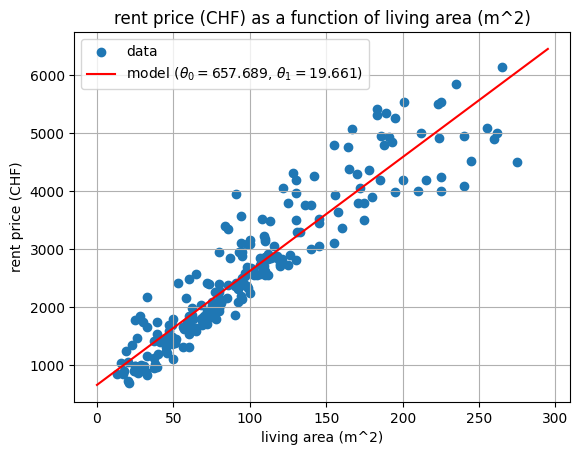

In [ ]:
# see Eq. (3), (4) and (5) of the MPW2 pdf
X = np.c_[np.ones(len(living_area)), living_area]
y = rent_price
theta = np.dot(np.dot(inv(np.dot(X.T, X)), X.T), y)

print("intercept (theta_0):", theta[0])  # should be around 658
print("slope (theta_1)    :", theta[1])  # should be around 19.7

x_curve = np.array(np.linspace(0, np.max(X) + 20, 200))
y_curve = theta[0] + theta[1] * x_curve

plot_data_prediction(
    living_area,
    rent_price,
    x_curve,
    y_curve,
    x_title='living area (m^2)',
    y_title='rent price (CHF)',
    theta_0=theta[0],
    theta_1=theta[1],
)

The values of $\theta_0$ and $\theta_1$ obtained above are your references for the rest of the exercises.
Parameter $\theta_1$ defines the slope, equal to the augmentation of the rent price for each additional square meter of living area. Parameter $\theta_0$ defines the intercept, equal to the rent price when the living area is zero. We can observe a price evolution of around 20 CHF per additional square meter ($\theta_1 = 19.7$).

b) Compute the overall MSE loss :

In [ ]:
def mse_loss(y_hat, y):

    return np.sum((y_hat - y)**2) / (2 * len(y))

y_hat = theta[0] + theta[1] * living_area
J = mse_loss(y_hat, y)
print("The total value of the loss is", J)  # should be around 105K

The total value of the loss is 104915.13056913581


This value is minimum with the optimal $\theta$. It is pretty large because the data is noisy and the model is very simple (linear regression). Another frequently used metric is the root mean squared error (RMSE) which is the square root of the MSE. It is in the same unit as the target variable and is easier to interpret. Other commonly used metrics are the mean absolute error (MAE) and the mean absolute percentage error (MAPE). MAE is the average of the absolute  differences between the predicted values and the actual values. It is also in the same unit as the target variable and is less sensitive to outliers than the MSE. MAPE is the average of the absolute percentage differences between the predicted values and the actual values. It is a relative error metric that is useful when the target variable has a wide range of values.

In [ ]:
def rmse_loss(y_hat, y):

    return np.sqrt(2*mse_loss(y_hat, y))

def mae_loss(y_hat, y):
    return np.sum(np.abs(y_hat - y)) / len(y)

def mape_loss(y_hat, y):
    return np.sum(np.abs((y_hat - y) / y)) / len(y)

rmse = rmse_loss(y_hat, y)
mae = mae_loss(y_hat, y)
mape = mape_loss(y_hat, y)
mape_percent = 100 * mape
print("The total value of the RMSE loss is", round(rmse))
print("The total value of the MAE loss is", round(mae))
print("The total value of the MAPE loss is", f"{mape_percent:.1f}%")

The total value of the RMSE loss is 458
The total value of the MAE loss is 347
The total value of the MAPE loss is 14.6%



With **MSE**, we obtain a metric very sensitive to outliers. That's why we obtain such a high value, around y**2.

With **RMSE**, we obtain a value in the same range as y, better than y**2.

The value obtain with **MAE** is very similar to RMSE. The little gap between them is surely due to outliers that triggered RMSE.

Finally, with **MAPE** we obtain the percentage of the reu value. With this datasets, 14.6% of the values are well represented by our regression model.

**What could be the problem with MAPE ?**

The formula of MAPE is **(y_hat - y) / y)**, so if y=0, MAPE is undefined. Furthermore, mape(y_hat, y) isn't equal to mape(y, y_hat).

## 4. Stochastic gradient descent for linear regression with computational graph

### 4.1 Graph creation

We need now to create a computational graph for the linear regression model and the MSE loss. The graph should have the following structure:

![Linear regression computational graph](../images/linear-regression-graph.jpg)

Before creating the graph, you need to complete the Python code __cgnodes.py__ with a new operator node __MSELossNode(MetaNode)__ that computes the MSE loss between the predicted values and the actual values. The node should have two inputs: the predicted values and the actual values. The node should have one output: the MSE loss.

Then you can create the graph below.

In [ ]:
class MSELossNode(MetaNode):
    def __init__(self, pred: ValueNode, target: ValueNode, out: ValueNode):
        super().__init__()
        pred.connect_to(self)
        target.connect_to(self)
        self.connect_to(out)
        self._received_count = 0

    def get_parent_values(self):
        return self.parents[0].v, self.parents[1].v

    def receive_parent_value(self, v):
        if self._received_count >= 2:
            raise Exception("Already received both inputs")
        self._received_count += 1
        if self._received_count == 2:
            self.input_ready = True

    def reset_values(self):
        self._received_count = 0
        self.input_ready = False
        for node in self.children:
            node.reset_values()

    def forward(self):
        if self.input_ready:
            i, y = self.get_parent_values()
            j = ((i - y) ** 2)/2

            for node in self.children:
                node.receive_parent_value(j)
                node.forward()

    def backward(self, grad_z):
        i, y = self.get_parent_values()
        diff = i - y


        grad_common = diff * grad_z

        self.parents[0].backward(grad_common)
        self.parents[1].backward(-grad_common)

In [ ]:
### TO COMPLETE  - CREATE THE GRAPH ###
# first create all ValueNode objects
theta_0 = ValueNode()
theta_1 = ValueNode()
x = ValueNode()
y = ValueNode()
j = ValueNode()
s = ValueNode()
i = ValueNode()

# then create all <Operator>Node objects
h = MultiplyNode(theta_1, x,s)
v= AddNode([theta_0, s],i)
mse = MSELossNode(y,i, j)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x, theta_0, theta_1, y], [j])

In [ ]:
# try a forward pass with dummy values
cg.reset_values()
cg.forward([0.0, 0.0, 0.0, 1.0])
print(j.v)  # should give 0.5

0.5


In [ ]:
cg.backward()
print(theta_0.grad_v, theta_1.grad_v)  # should give -1.0 -0.0

-1.0 -0.0


### 4.2 Plain vanilla stochastic gradient descent

In [ ]:
# this function plots the evolution of the loss and the parameters during training, as well
# as the data points and the model curve at the end of training. The last value of the
# evolution of theta_0 and theta_1 is used to plot the model curve.
def plot_training_log(loss_evolution, t0_evolution, t1_evolution, x, y):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10,7))
    fig.suptitle('Training log')
    ax1.plot(t0_evolution)
    ax1.set_title('theta 0')
    ax2.plot(t1_evolution)
    ax2.set_title('theta 1')
    ax3.plot(loss_evolution)
    ax3.set_title('loss')
    ax4.scatter(x, y, s=1.0)
    x_curve = np.array(np.linspace(np.min(x), np.max(x), 2))
    y_curve = t0_evolution[-1] + t1_evolution[-1] * x_curve  # use last value of evolution as thetas
    ax4.plot(x_curve, y_curve, color='red')
    ax4.set_title('points and model output')
    fig.tight_layout()

Complete the code below to implement the stochastic gradient descent algorithm for linear regression. Make sure you understand the code and the algorithm before completing it. We will bring incremental evolution to this code so make sure you understand each lines of it. The code is pretty straightforward, but you can ask for help if you have any questions.

intercept (theta_0): 1.0076205554084088
slope (theta_1)    : 24.390994902037008
The total value of the loss is 163539.4578561296


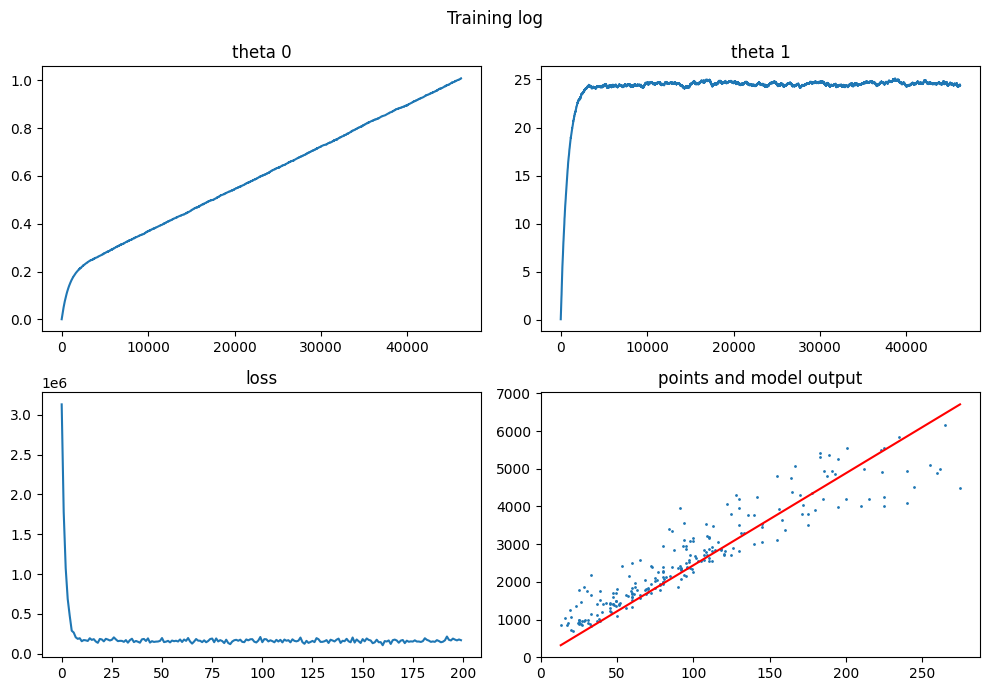

In [ ]:
alpha = 0.0000001     # learning rate
epochs = 200          # number of epochs (an epoch is a loop over the whole training set)
N = len(living_area)  # number of samples in the training set
t0 = 0.0              # initial value of theta_0
t1 = 0.0              # initial value of theta_1

loss_evolution = []  # to log the evolution of the loss
t0_evolution = []    # to log the evolution of theta_0
t1_evolution = []    # to log the evolution of theta_1

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))  # random sampling in the training set
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        t0 = t0 -alpha *theta_0.grad_v  # update rule for theta_0
        t1 = t1 -alpha *theta_1.grad_v  # update rule for theta_1
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)


**Your observations**

- Evolution of the loss:

The loss decreases drastically from the beginning of the training to around **163K**, which is good. The model can learn without a too heavy loss.
- Evolution of theta_1:

From the beginning, theta_1 stagnates around **24.3**. That means that the slope of the regression line converged early.
- Evolution of theta_0:

The value of theta_0 continues to increase to finish around **1**. The regression line will have an intercept equal to 1. The convergence is not over though.


### 4.3 Batched gradient descent

Modify the code from the above stochastic gradient descent to implement a batched gradient descent algorithm. The idea is to compute the gradients on a batch of samples instead of a single sample. This can help to smooth the evolution of the parameters and the loss, and can also speed up the convergence.

intercept (theta_0): 0.4772761313246392
slope (theta_1)    : 24.518279150126116
The total value of the loss is 163525.38854405293


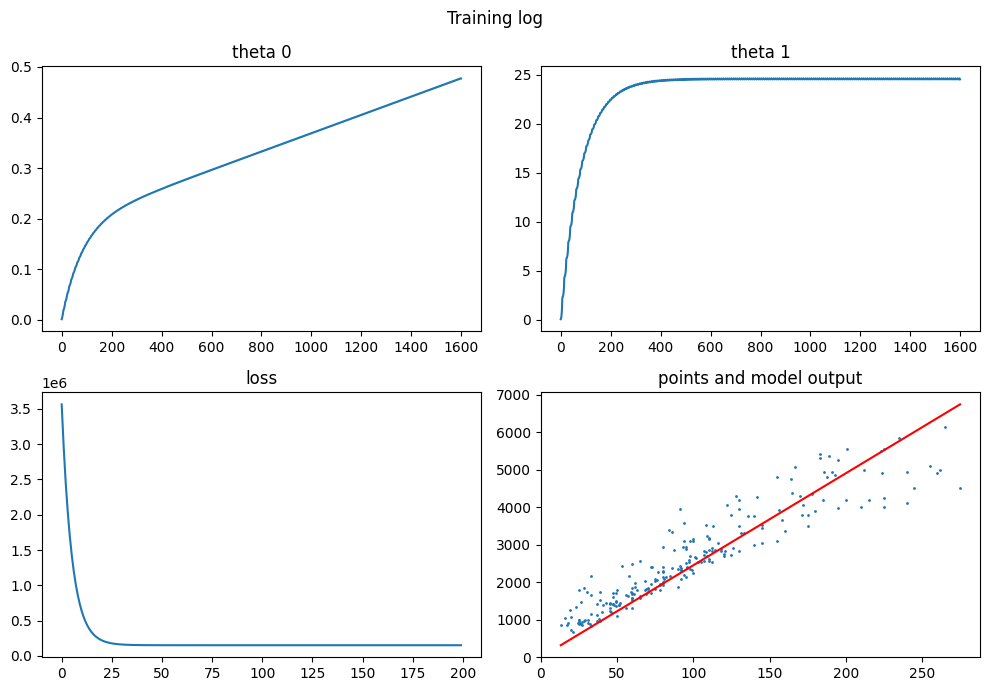

In [ ]:
alpha = 0.000001  # learning rate can be higher than in the plain vanilla SGD
                  # as we will average the gradients over a batch of samples
epochs = 200
batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for step in range(n_steps):
        t0mean = 0
        t1mean = 0
        batchloss = 0
        for i in range(batch_size):
            n = (step * batch_size + i)%N
            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()
            t0mean += theta_0.grad_v
            t1mean += theta_1.grad_v
            batchloss +=j.v
        t0 = t0 -alpha *t0mean/batch_size  # update rule for theta_0
        t1 = t1 -alpha *t1mean/batch_size  # update rule for theta_1
        epoch_loss += batchloss/batch_size
        t0_evolution.append(t0)
        t1_evolution.append(t1)
        # compute the gradients and update theta_0 and theta_1 with the average
        # of the gradients over the batch


    loss_evolution.append(epoch_loss / n_steps)
    epoch_loss = 0.0

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations**

- Evolution of theta_0 and theta_1:

theta_1 and theta_0 remain similar to the last model but their evolutions are much more smooth.

- Do we still have the same observation as in the plain stochastic version regarding the convergence of theta_1 and the slow evolution of theta_0 ?

We retrieve the same evolution of these two parameters but this is more stable with the technique of batch gradient descent. theta_1 has converged to the value of 24 (same as previous) and theta_0 still converges.

- Can we use larger learning rates than in the plain stochastic version ?

Using batch can allow us to use larger learning rate because it helps stabilizing the model. Usually, a larger learning rate implies instability. It would be impossible to do it without batches.

## 5. Optimizers
### 5.1 Idea 1: use different learning rates for $\theta_0$ and $\theta_1$

This is a very simple idea that can help to speed up the convergence of $\theta_0$ and $\theta_1$. We can use a larger learning rate for $\theta_1$ than for $\theta_0$ as $\theta_1$ converges faster than $\theta_0$. This idea is actually a first step towards RMSProp which is an optimizer that uses different learning rates for different parameters based on the history of the gradients.

intercept (theta_0): 658.2390599334236
slope (theta_1)    : 19.535533778213317
The total value of the loss is 105013.5807268108


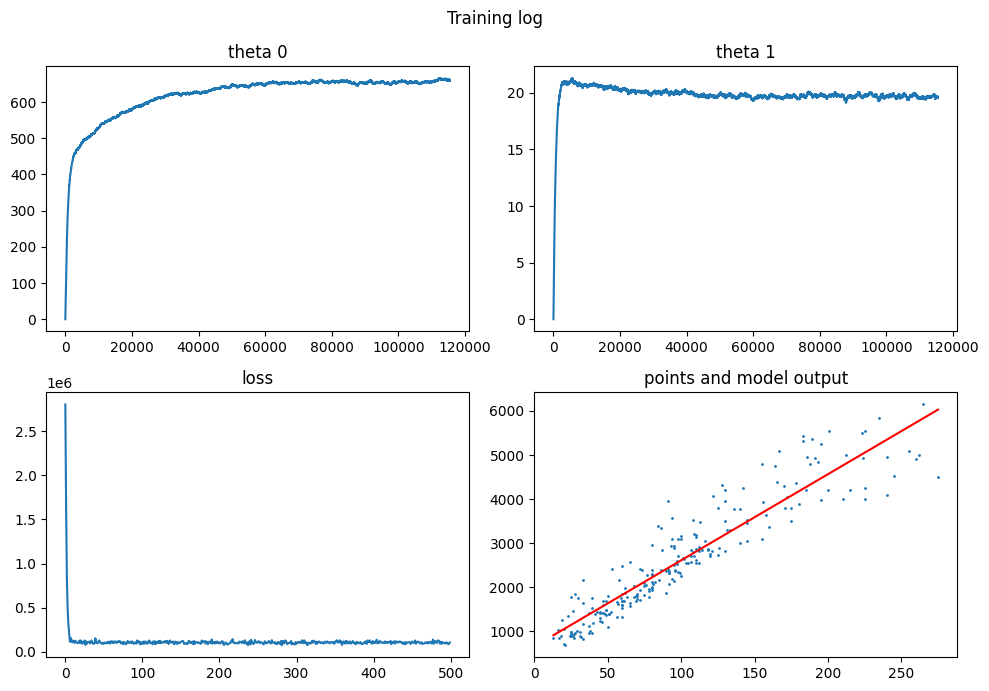

In [ ]:
alpha_t0 = 0.00025    # learning rate for theta_0
alpha_t1 = 0.0000001  # learning rate for theta_1
epochs = 500          # number of epochs (an epoch is a loop over the whole training set)
N = len(living_area)  # number of samples in the training set
t0 = 0.0              # initial value of theta_0
t1 = 0.0              # initial value of theta_1

loss_evolution = []  # to log the evolution of the loss
t0_evolution = []    # to log the evolution of theta_0
t1_evolution = []    # to log the evolution of theta_1

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))  # random sampling in the training set
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        t0 = t0 -alpha_t0 *theta_0.grad_v  # update rule for theta_0
        t1 = t1 -alpha_t1 *theta_1.grad_v  # update rule for theta_1
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)



**Your observations**

- We can obtain similar results with optimizer and batch gradient descent, regarding the loss. These two techniques improve the performances of the model and reduce the loss over the epochs.
- theta_1 follows the same evolution with optimizer than with the previous techniques, and converges to the value of 19 (it was 24 previously). theta_1 converges very quickly while theta_0 needs more time to stabilize around its converged final value. However, theta_0 succeeds to finally converge towards the value of 658 from the epoch ~80000.
- We can note that the curves are a bit more unstable than with batch gradient descent.


### 5.2 Idea 2: accelerate the movement of the parameters with the principle of momentum

The idea is to accelerate the modification of the parameters introducing a memory about the previous evolutions of the gradients. If the gradients are always in the same direction, we can accelerate the movement of the parameter updates in that direction. This is done by introducing a new variable called *momentum* that accumulates the gradients over time, and using this variable to update the parameters instead of the current gradient. The analogy would be to think of a ball rolling down the hill of parameter space, accelerating when the successive values of the gradients are aligned. The classical momentum equations are the following:

\begin{equation*}
	m^{(t+1)} = \beta \cdot m^{(t)} + \alpha \cdot grad^{(t)}
\end{equation*}

\begin{equation*}
    \theta^{(t+1)} = \theta^{(t)} - m^{(t+1)}
\end{equation*}

The value $\beta$ is multiplying the previous momentum and controls how much inertia we inject in the system. Values of $\beta$ above $1.0$ will make the system diverge and overflow. Too small $\beta$ value will not help if the way to the optimal value of the $\theta$ is far. A frequently used default is $\beta = 0.9$, but this is a value that needs to be tuned for each specific problem.

In our previous experiments, the parameter $\theta_0$ has gradients that seem to go always in the same direction. Convergence would benefit from this memory, accelerating the growth of $\theta_0$. This is less the case for $\theta_1$ which shows a quick convergence to a plateau, with gradients that are not always in the same direction. This is why we can expect a bigger improvement for $\theta_0$ than for $\theta_1$ with this idea. To handle this, we recommend to introduce two new variables `momentum_t0` and `momentum_t1` that accumulate the gradients of $\theta_0$ and $\theta_1$ respectively. We then use these momentum variables to update the parameters instead of the current gradients.

Complete the code below to implement the momentum optimizer for linear regression.

intercept (theta_0): 656.4706250258191
slope (theta_1)    : 19.8443922528274
The total value of the loss is 105117.36403788975


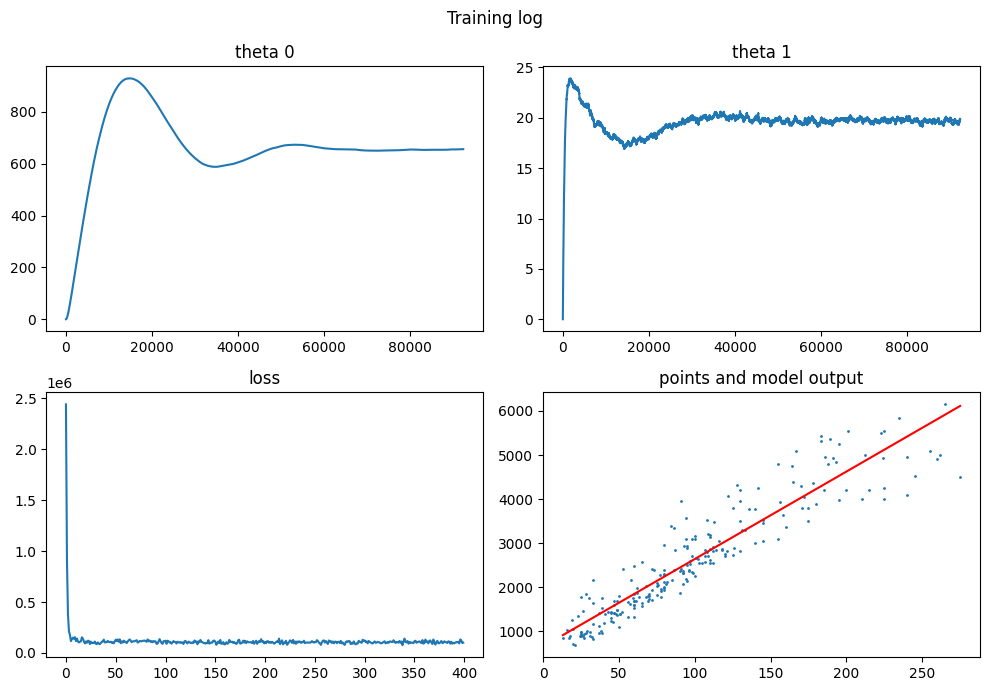

In [ ]:
alpha = 0.0000001
beta_momentum_t0 = 0.9999
beta_momentum_t1 = 0.5000
epochs = 400
N = len(living_area)
t0 = 0.0              # initial value of theta_0
t1 = 0.0              # initial value of theta_1
momentum_t0=0.0
momentum_t1=0.0
loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        momentum_t0 = beta_momentum_t0 *momentum_t0 + alpha *theta_0.grad_v
        momentum_t1 = beta_momentum_t1 *momentum_t1 + alpha *theta_1.grad_v
        t0 = t0 -momentum_t0  # update rule for theta_0
        t1 = t1 -momentum_t1  # update rule for theta_1
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)



**Your observations**.

- theta_0 and theta_1 reached the same value as before but faster. Previously, theta_0 converged around 80000. Now, shortly after 4000 and even before 60000, theta_0 reached the value of 656.
- The same behaviour can be observed for theta_1 but it's particularly visible for theta_0. Indeed, the momentum helped theta_0, which had gradients that pointed to the same direction, to converge quicker.
- The performance of the model remains very good with a loss that decreases from the begining of the training.


## Optional objectives

Pick at least 2 of the following optional objectives to further explore and analyze the performance of your models:

- Investigate the use of 2nd order model instead of the simple linear model.
- Re-implement and experiment with more advanced optimizers such as RMSProp, Nesterov or **Adam**.
- Implement an **early stopping** strategy in your training loop.
- Implement a *Learning Rate Decay on Plateau* strategy in the training loop.
- Normalize the input data with a zero norm approach and compare to your experiments without normalization.


#### **1. Early stopping**

early stopping triggered
intercept (theta_0): 0.21647603276250715
slope (theta_1)    : 23.116100213167655
The total value of the loss is 176780.95687874098


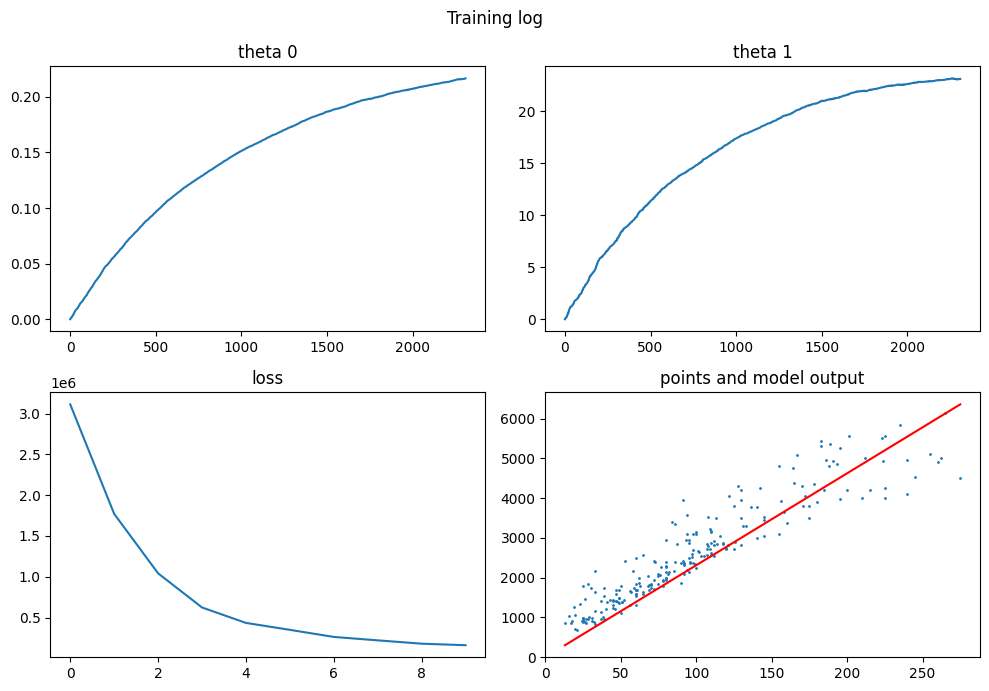

In [ ]:
alpha = 0.0000001
epochs = 200
N = len(living_area)
t0 = 0.0              # initial value of theta_0
t1 = 0.0              # initial value of theta_1

loss_evolution = []
t0_evolution = []
t1_evolution = []

patience =10 #critere d'arret
best_loss = 100000
patience_ctr = 0

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        t0 = t0 -alpha *theta_0.grad_v  # update rule for theta_0
        t1 = t1 -alpha *theta_1.grad_v  # update rule for theta_1
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    train_loss = epoch_loss / n_steps
    loss_evolution.append(train_loss) #loss d'entrainement

    if train_loss < best_loss - 1e-6:
        best_loss = train_loss
        patience_ctr = 0
        best_t0=t0
        best_t1=t1

    else:
        patience_ctr += 1
        if patience_ctr >= patience:
          print("early stopping triggered")
          break

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations**

- Wa can clearly see that early stopping prevents the model from converging. theta_0 and theta_1 aren't stablized around theirs final values.
- The loss could also decrease more but we stopped the training far too soon.



#### **2. Adam**
To ensure that we only use the previous declared function (backward, forward...), we will reimplement Adam by hand to avoir using loss.backward() or optimizer.zero_grad() that belong to the torch library.

intercept (theta_0): 340.0464690301732
slope (theta_1)    : 21.962217220742303
The total value of the loss is 118622.01492219049


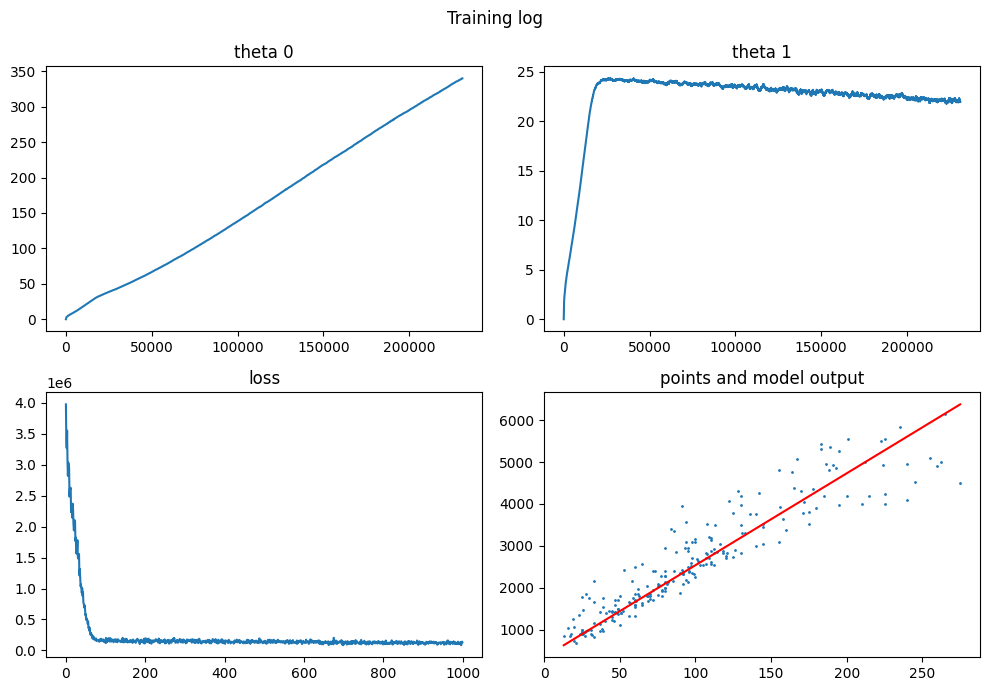

In [ ]:
import numpy as np

alpha = 0.01       # higher alpha to allow Adam to really update the parameter at each iteration
beta1 = 0.9        # Coef gradients (1st moment)
beta2 = 0.999      # Coef gradients*2 (2nd moment)
epsilon = 1e-8     # avoid division par zéro
epochs = 1000
N = len(living_area)

t0 = 0.0
t1 = 0.0

# Init des moments pour Adam
m_t0, v_t0 = 0.0, 0.0
m_t1, v_t1 = 0.0, 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    epoch_loss = 0.0

    for step in range(N):
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()

        grad_t0 = theta_0.grad_v
        grad_t1 = theta_1.grad_v

        # Adam : update of the moment
        m_t0 = beta1 * m_t0 + (1 - beta1) * grad_t0
        v_t0 = beta2 * v_t0 + (1 - beta2) * (grad_t0 ** 2)
        m_t1 = beta1 * m_t1 + (1 - beta1) * grad_t1
        v_t1 = beta2 * v_t1 + (1 - beta2) * (grad_t1 ** 2)

        # Adam : bias correction
        m_t0_hat = m_t0 / (1 - beta1 ** (epoch + 1))
        v_t0_hat = v_t0 / (1 - beta2 ** (epoch + 1))
        m_t1_hat = m_t1 / (1 - beta1 ** (epoch + 1))
        v_t1_hat = v_t1 / (1 - beta2 ** (epoch + 1))

        t0 = t0 - alpha * m_t0_hat / (np.sqrt(v_t0_hat) + epsilon)
        t1 = t1 - alpha * m_t1_hat / (np.sqrt(v_t1_hat) + epsilon)

        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)

    train_loss = epoch_loss / n_steps
    loss_evolution.append(train_loss)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations**
- The loss is well reduced.
- Theta_1 has converged but this is not the case of theta_0, even if Adam accelerates the convergence.
- This solution isn't our best, but Adam is more efficient than the vanilla gradient descent. The final loss with Adam is lower than the one with stochastic gradient descent.



____________
#### **Conclusion**
During this pratical work, we studied how to build a simple computational graph to create a model able to predict the rent of a flat in Lausanne, based on its size.
The model was a first order equation to solve by finding its two parameters : theta_1 and theta_0.

We used and compared different losses : MSE, RMSE, MAE and MAPE.
Several training strategies were tested : plain vanilla stochastic gradient descent or batched gradient descent. We also tried RMSprop and the momentum to speed up the convergence od theta_0 and theta_1

Eventually, we decided to implement early stopping and Adam to see if they can accelerate the convergence while stabilizing the training process.

We can conclude by saying that the momentum seems to be one of the best strategies to apply. With it, theta_0 and theta_1 can converge with a low loss.